In [41]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import joblib
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

In [2]:
data_train = pd.read_csv('train.csv')
data_store = pd.read_csv('store.csv')
data_calender = pd.read_csv('calendar.csv')
print(data_train.shape)
print(data_store.shape)
print(data_calender.shape)

(27360, 9)
(30, 10)
(912, 8)


In [3]:
data_store.isnull().sum()

Store                         0
StoreType                     0
Assortment                    0
CompetitionDistance           3
CompetitionOpenSinceMonth     3
CompetitionOpenSinceYear      3
Promo2                        0
Promo2SinceWeek              19
Promo2SinceYear              19
PromoInterval                19
dtype: int64

In [4]:
df = pd.merge(data_train, data_store, on='Store', how='left')

In [5]:
df.isnull().sum()

Store                            0
Date                             0
DayOfWeek                        0
Sales                            0
Customers                        0
Open                             0
Promo                            0
StateHoliday                     0
SchoolHoliday                    0
StoreType                        0
Assortment                       0
CompetitionDistance           2736
CompetitionOpenSinceMonth     2736
CompetitionOpenSinceYear      2736
Promo2                           0
Promo2SinceWeek              17328
Promo2SinceYear              17328
PromoInterval                17328
dtype: int64

In [6]:
df['Promo2'].value_counts()

Promo2
0    17328
1    10032
Name: count, dtype: int64

In [7]:
df.head(5)

,Store,Date,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2022-01-01,6,6093,126,1,0,a,0,a,extra,186.0,4.0,2017.0,1,37.0,2022.0,"Jan,Apr,Jul,Okt"
1,1,2022-01-02,7,0,0,0,1,0,0,a,extra,186.0,4.0,2017.0,1,37.0,2022.0,"Jan,Apr,Jul,Okt"
2,1,2022-01-03,1,5692,128,1,1,0,0,a,extra,186.0,4.0,2017.0,1,37.0,2022.0,"Jan,Apr,Jul,Okt"
3,1,2022-01-04,2,4148,86,1,0,0,0,a,extra,186.0,4.0,2017.0,1,37.0,2022.0,"Jan,Apr,Jul,Okt"
4,1,2022-01-05,3,4069,100,1,0,0,0,a,extra,186.0,4.0,2017.0,1,37.0,2022.0,"Jan,Apr,Jul,Okt"


In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'].dtype

dtype('<M8[us]')

In [9]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [10]:
df['PromoInterval'].unique()

<StringArray>
['Jan,Apr,Jul,Okt', nan, 'Mar,Jun,Sep,Des']
Length: 3, dtype: str

In [11]:
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sept', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

df['Month_abbr'] = df['Month'].map(month_map)

In [12]:
df['IsMonthInPromoInterval'] = df.apply(
    lambda row: row['Month_abbr'] in row['PromoInterval'].split(',') if pd.notna(row['PromoInterval']) else False,
    axis=1
)

In [13]:
df[['Month_abbr', 'PromoInterval', 'IsMonthInPromoInterval']].sample(10)

,Month_abbr,PromoInterval,IsMonthInPromoInterval
25230,Aug,NaN,False
1368,Apr,NaN,False
754,Jan,"Jan,Apr,Jul,Okt",True
26215,Nov,NaN,False
12392,Jun,NaN,False
1391,Apr,NaN,False
21660,Nov,"Jan,Apr,Jul,Okt",False
15905,Feb,NaN,False
4927,Jan,NaN,False
3348,Sept,"Jan,Apr,Jul,Okt",False


In [14]:
df['WeekofYear'] = df['Date'].dt.isocalendar().week.astype('int32')

In [15]:
df['PromoStarted'] = (df['Year'] > df['Promo2SinceYear']) | ((df['Year'] == df['Promo2SinceYear']) & (df['WeekofYear'] >= df['Promo2SinceWeek']))
df['IsPromo2ActiveOnThisDate'] = (df['Promo2'] == 1) & df['PromoStarted'] & df['IsMonthInPromoInterval']

In [16]:
df[['Store', 'Date', 'Promo2', 'Promo2SinceYear', 'Promo2SinceWeek', 'PromoInterval', 
    'Year', 'WeekofYear', 'IsMonthInPromoInterval', 'PromoStarted', 'IsPromo2ActiveOnThisDate']].sample(10)

,Store,Date,Promo2,Promo2SinceYear,Promo2SinceWeek,PromoInterval,Year,WeekofYear,IsMonthInPromoInterval,PromoStarted,IsPromo2ActiveOnThisDate
13832,16,2022-06-02,0,NaN,NaN,NaN,2022,22,False,False,False
2058,3,2022-08-23,0,NaN,NaN,NaN,2022,34,False,False,False
2065,3,2022-08-30,0,NaN,NaN,NaN,2022,35,False,False,False
2634,3,2024-03-21,0,NaN,NaN,NaN,2024,12,False,False,False
27282,30,2024-04-14,1,2022.0,18.0,"Mar,Jun,Sep,Des",2024,15,False,True,False
544,1,2023-06-29,1,2022.0,37.0,"Jan,Apr,Jul,Okt",2023,26,False,True,False
21826,24,2024-04-30,1,2023.0,25.0,"Jan,Apr,Jul,Okt",2024,18,True,True,True
14351,16,2023-11-03,0,NaN,NaN,NaN,2023,44,False,False,False
11717,13,2024-02-13,1,2021.0,24.0,"Jan,Apr,Jul,Okt",2024,7,False,True,False
21850,24,2024-05-24,1,2023.0,25.0,"Jan,Apr,Jul,Okt",2024,21,False,True,False


In [17]:
df[df['Promo2']==1].value_counts()

Store  Date        DayOfWeek  Sales  Customers  Open  Promo  StateHoliday  SchoolHoliday  StoreType  Assortment  CompetitionDistance  CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  Promo2SinceWeek  Promo2SinceYear  PromoInterval    Month  Year  Month_abbr  IsMonthInPromoInterval  WeekofYear  PromoStarted  IsPromo2ActiveOnThisDate
1      2022-01-01  6          6093   126        1     0      a             0              a          extra       186.0                4.0                        2017.0                    1       37.0             2022.0           Jan,Apr,Jul,Okt  1      2022  Jan         True                    52          True          True                        1
       2022-01-02  7          0      0          0     1      0             0              a          extra       186.0                4.0                        2017.0                    1       37.0             2022.0           Jan,Apr,Jul,Okt  1      2022  Jan         True                    52      

In [18]:
test = pd.Series([2023, 2023, 2023])
compare_to = pd.Series([2022, np.nan, 2024])

print(test > compare_to)

0     True
1    False
2    False
dtype: bool


In [19]:
# Ambil baris dengan Promo2 == 0 saja
mask = df['Promo2'] == 0
df.loc[mask, ['Promo2', 'Promo2SinceYear', 'PromoStarted', 'IsPromo2ActiveOnThisDate']].head(10)

,Promo2,Promo2SinceYear,PromoStarted,IsPromo2ActiveOnThisDate
912,0,NaN,False,False
913,0,NaN,False,False
914,0,NaN,False,False
915,0,NaN,False,False
916,0,NaN,False,False
917,0,NaN,False,False
918,0,NaN,False,False
919,0,NaN,False,False
920,0,NaN,False,False
921,0,NaN,False,False


In [20]:
df['IsCompetitorActive'] = (df['Year'] > df['CompetitionOpenSinceYear']) | (df['Year'] == df['CompetitionOpenSinceYear']) & ((df['Month'] >= df['CompetitionOpenSinceMonth']))

In [21]:
mask = df['CompetitionDistance'].isna()
df.loc[mask, ['CompetitionDistance', 'CompetitionOpenSinceYear', 'IsCompetitorActive']].head(10)

,CompetitionDistance,CompetitionOpenSinceYear,IsCompetitorActive
1824,NaN,NaN,False
1825,NaN,NaN,False
1826,NaN,NaN,False
1827,NaN,NaN,False
1828,NaN,NaN,False
1829,NaN,NaN,False
1830,NaN,NaN,False
1831,NaN,NaN,False
1832,NaN,NaN,False
1833,NaN,NaN,False


In [22]:
df['EffectiveCompetitionDistance'] = np.where(
    df['IsCompetitorActive'], 
    df['CompetitionDistance'], 
    9999
)

In [23]:
mask = df['IsCompetitorActive'] == False
df.loc[mask, ['CompetitionDistance', 'IsCompetitorActive', 'EffectiveCompetitionDistance']].head(10)

,CompetitionDistance,IsCompetitorActive,EffectiveCompetitionDistance
1824,NaN,False,9999.0
1825,NaN,False,9999.0
1826,NaN,False,9999.0
1827,NaN,False,9999.0
1828,NaN,False,9999.0
1829,NaN,False,9999.0
1830,NaN,False,9999.0
1831,NaN,False,9999.0
1832,NaN,False,9999.0
1833,NaN,False,9999.0


In [24]:
mask2 = df['CompetitionDistance'].isna()
df.loc[mask2, ['CompetitionDistance', 'IsCompetitorActive', 'EffectiveCompetitionDistance']].head(10)

,CompetitionDistance,IsCompetitorActive,EffectiveCompetitionDistance
1824,NaN,False,9999.0
1825,NaN,False,9999.0
1826,NaN,False,9999.0
1827,NaN,False,9999.0
1828,NaN,False,9999.0
1829,NaN,False,9999.0
1830,NaN,False,9999.0
1831,NaN,False,9999.0
1832,NaN,False,9999.0
1833,NaN,False,9999.0


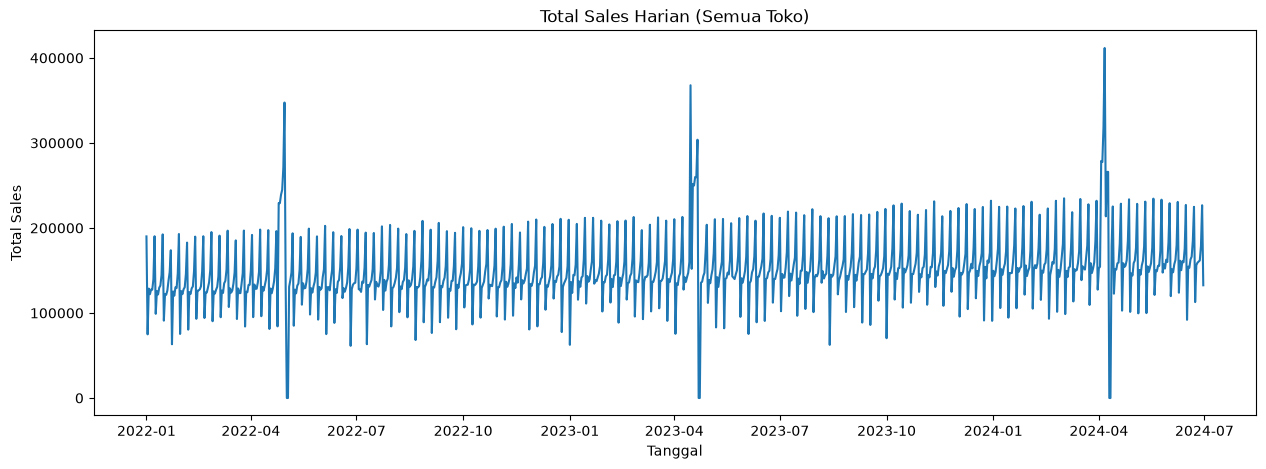

In [25]:
daily_sales = df.groupby('Date')['Sales'].sum()

plt.figure(figsize=(15,5))
plt.plot(daily_sales.index, daily_sales.values)
plt.title('Total Sales Harian (Semua Toko)')
plt.xlabel('Tanggal')
plt.ylabel('Total Sales')
plt.show()

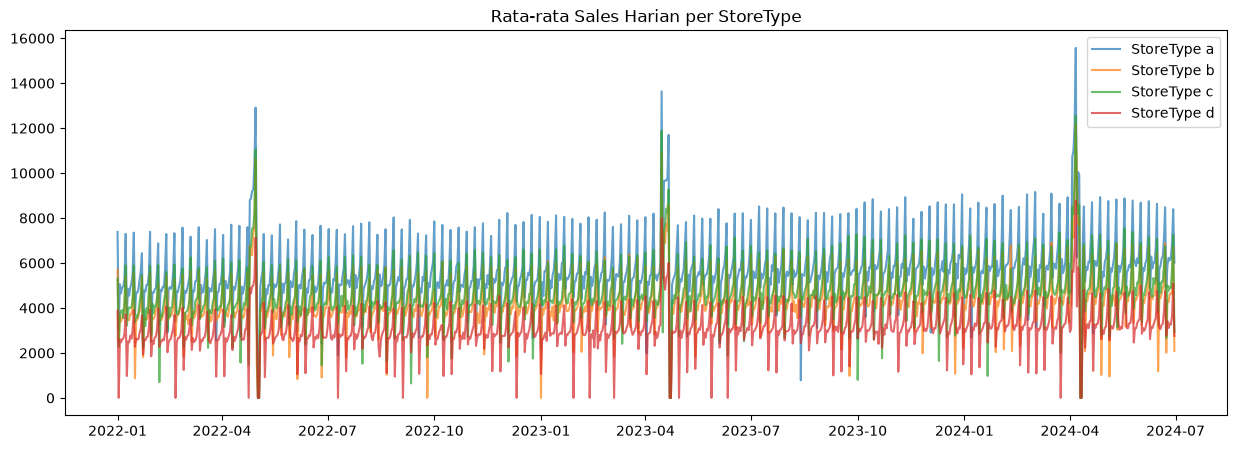

In [26]:
plt.figure(figsize=(15, 5))
for stype in sorted(df['StoreType'].unique()):
    subset = df[df['StoreType'] == stype].groupby('Date')['Sales'].mean()
    plt.plot(subset.index, subset.values, label=f'StoreType {stype}', alpha=0.7)
plt.title('Rata-rata Sales Harian per StoreType')
plt.legend()
plt.show()

In [27]:
df.groupby('StoreType')['Sales'].mean()

StoreType
a    5727.049479
b    4309.348026
c    4660.162829
d    3073.796053
Name: Sales, dtype: float64

In [28]:
df = df.sort_values(['Store', 'Date'])  # WAJIB urutkan dulu sebelum shift/rolling

df['Sales_lag_7'] = df.groupby('Store')['Sales'].shift(7)
df['Sales_rolling_mean_7'] = df.groupby('Store')['Sales'].transform(
    lambda x: x.shift(1).rolling(window=7).mean()
)

In [29]:
df[df['Store']==1][['Date','Sales','Sales_lag_7','Sales_rolling_mean_7']].head(15)

,Date,Sales,Sales_lag_7,Sales_rolling_mean_7
0,2022-01-01,6093,NaN,NaN
1,2022-01-02,0,NaN,NaN
2,2022-01-03,5692,NaN,NaN
3,2022-01-04,4148,NaN,NaN
4,2022-01-05,4069,NaN,NaN
5,2022-01-06,4471,NaN,NaN
6,2022-01-07,4915,NaN,NaN
7,2022-01-08,7723,6093.0,4198.285714
8,2022-01-09,5523,0.0,4431.142857
9,2022-01-10,5073,5692.0,5220.142857


In [30]:
df_model = df[df['Open'] == 1].copy()
print(df.shape, "->", df_model.shape)

(27360, 29) -> (25565, 29)


In [31]:
print(df_model['Date'].min(), df_model['Date'].max())

2022-01-01 00:00:00 2024-06-30 00:00:00


In [32]:
cutoff_date = '2024-01-01'  # isi sendiri
train_set = df_model[df_model['Date'] < cutoff_date]
test_set = df_model[df_model['Date'] >= cutoff_date]

print("Train:", train_set['Date'].min(), "-", train_set['Date'].max(), "| shape:", train_set.shape)
print("Test:", test_set['Date'].min(), "-", test_set['Date'].max(), "| shape:", test_set.shape)

Train: 2022-01-01 00:00:00 - 2023-12-31 00:00:00 | shape: (20472, 29)
Test: 2024-01-01 00:00:00 - 2024-06-30 00:00:00 | shape: (5093, 29)


In [33]:
train_set[['Sales_lag_7', 'Sales_rolling_mean_7']].isna().sum()

Sales_lag_7             194
Sales_rolling_mean_7    194
dtype: int64

In [34]:
train_set_clean = train_set.dropna(subset=['Sales_lag_7', 'Sales_rolling_mean_7']).copy()
test_set_clean = test_set.dropna(subset=['Sales_lag_7', 'Sales_rolling_mean_7']).copy()

print(train_set.shape, "->", train_set_clean.shape)
print(test_set.shape, "->", test_set_clean.shape)

(20472, 29) -> (20278, 29)
(5093, 29) -> (5093, 29)


In [35]:
train_set_clean.columns.tolist()

['Store',
 'Date',
 'DayOfWeek',
 'Sales',
 'Customers',
 'Open',
 'Promo',
 'StateHoliday',
 'SchoolHoliday',
 'StoreType',
 'Assortment',
 'CompetitionDistance',
 'CompetitionOpenSinceMonth',
 'CompetitionOpenSinceYear',
 'Promo2',
 'Promo2SinceWeek',
 'Promo2SinceYear',
 'PromoInterval',
 'Month',
 'Year',
 'Month_abbr',
 'IsMonthInPromoInterval',
 'WeekofYear',
 'PromoStarted',
 'IsPromo2ActiveOnThisDate',
 'IsCompetitorActive',
 'EffectiveCompetitionDistance',
 'Sales_lag_7',
 'Sales_rolling_mean_7']

In [36]:
train_set_clean['Open'].unique()

array([1])

In [37]:
exclude_cols = [
    'Sales', 'Customers', 'Open', 'Date', 'Month_abbr', 'PromoStarted',
    'CompetitionDistance', 'Promo2SinceWeek', 'Promo2SinceYear',
    'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'PromoInterval'
]

feature_cols = [col for col in train_set_clean.columns if col not in exclude_cols]

X_train = train_set_clean[feature_cols]
y_train = train_set_clean['Sales']

X_test = test_set_clean[feature_cols]
y_test = test_set_clean['Sales']

print(feature_cols)
print(X_train.shape, X_test.shape)

['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'Promo2', 'Month', 'Year', 'IsMonthInPromoInterval', 'WeekofYear', 'IsPromo2ActiveOnThisDate', 'IsCompetitorActive', 'EffectiveCompetitionDistance', 'Sales_lag_7', 'Sales_rolling_mean_7']
(20278, 17) (5093, 17)


In [40]:
cat_cols = ['StateHoliday', 'StoreType', 'Assortment']

for cols in cat_cols :
    X_train[cols] = X_train[cols].astype('category')
    X_test[cols] = X_test[cols].astype('category')
    
print(X_train.dtypes)


Store                              int64
DayOfWeek                          int64
Promo                              int64
StateHoliday                    category
SchoolHoliday                      int64
StoreType                       category
Assortment                      category
Promo2                             int64
Month                              int32
Year                               int32
IsMonthInPromoInterval              bool
WeekofYear                         int32
IsPromo2ActiveOnThisDate            bool
IsCompetitorActive                  bool
EffectiveCompetitionDistance     float64
Sales_lag_7                      float64
Sales_rolling_mean_7             float64
dtype: object


In [42]:
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)
model.fit(
    X_train, y_train,
    categorical_feature=['StateHoliday', 'StoreType', 'Assortment']
)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003452 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 670
[LightGBM] [Info] Number of data points in the train set: 20278, number of used features: 17
[LightGBM] [Info] Start training from score 5234.241888


In [43]:
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Rata-rata Sales aktual (test set): {y_test.mean():.2f}")

MAE: 670.74
RMSE: 1195.21
Rata-rata Sales aktual (test set): 5906.11


In [44]:
mae_percentage = (670.74 / 5906.11) * 100
print(f"MAE sebagai persentase rata-rata Sales: {mae_percentage:.1f}%")

MAE sebagai persentase rata-rata Sales: 11.4%


In [45]:
errors = np.abs(y_test.values - y_pred)
worst_idx = np.argsort(errors)[-10:]  # 10 error terbesar

test_set_clean.iloc[worst_idx][['Date', 'Store', 'Sales']].assign(
    Predicted=y_pred[worst_idx],
    Error=errors[worst_idx]
)

,Date,Store,Sales,Predicted,Error
18153,2024-04-05,20,13390,6091.930135,7298.069865
5393,2024-04-13,6,9053,16375.022639,7322.022639
27281,2024-04-13,30,8711,16063.900007,7352.900007
20897,2024-04-13,23,8600,16136.891259,7536.891259
5386,2024-04-06,6,17742,10042.322652,7699.677348
6305,2024-04-13,7,7095,15303.460919,8208.460919
14506,2024-04-06,16,17490,9266.990172,8223.009828
20890,2024-04-06,23,19999,11718.538934,8280.461066
9041,2024-04-13,10,7098,15763.260189,8665.260189
4489,2024-04-21,5,1117,9838.151609,8721.151609


In [46]:
calendar_df = pd.read_csv('calendar.csv', parse_dates=['Date'])

train_set_clean = train_set_clean.merge(
    calendar_df[['Date', 'IsLebaranShoppingWindow']], 
    on='Date', 
    how='left'
)
test_set_clean = test_set_clean.merge(
    calendar_df[['Date', 'IsLebaranShoppingWindow']], 
    on='Date', 
    how='left'
)

print(train_set_clean['IsLebaranShoppingWindow'].sum())
print(test_set_clean['IsLebaranShoppingWindow'].sum())

389
200


In [47]:
feature_cols_v2 = feature_cols + ['IsLebaranShoppingWindow']

X_train_v2 = train_set_clean[feature_cols_v2]
y_train_v2 = train_set_clean['Sales']

X_test_v2 = test_set_clean[feature_cols_v2]
y_test_v2 = test_set_clean['Sales']

for col in cat_cols:
    X_train_v2[col] = X_train_v2[col].astype('category')
    X_test_v2[col] = X_test_v2[col].astype('category')

model_v2 = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

model_v2.fit(
    X_train_v2, y_train_v2,
    categorical_feature=cat_cols
)

y_pred_v2 = model_v2.predict(X_test_v2)

mae_v2 = mean_absolute_error(y_test_v2, y_pred_v2)
rmse_v2 = mean_squared_error(y_test_v2, y_pred_v2) ** 0.5

print(f"MAE sebelum: 670.74  | sesudah: {mae_v2:.2f}")
print(f"RMSE sebelum: 1195.21 | sesudah: {rmse_v2:.2f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001670 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 672
[LightGBM] [Info] Number of data points in the train set: 20278, number of used features: 18
[LightGBM] [Info] Start training from score 5234.241888
MAE sebelum: 670.74  | sesudah: 466.33
RMSE sebelum: 1195.21 | sesudah: 631.49


In [48]:
errors_v2 = np.abs(y_test_v2.values - y_pred_v2)
worst_idx_v2 = np.argsort(errors_v2)[-10:]

test_set_clean.iloc[worst_idx_v2][['Date', 'Store', 'Sales']].assign(
    Predicted=y_pred_v2[worst_idx_v2],
    Error=errors_v2[worst_idx_v2]
)

,Date,Store,Sales,Predicted,Error
3191,2024-05-24,19,1315,5455.760323,4140.760323
1569,2024-02-09,10,2019,6219.725572,4200.725572
1082,2024-03-05,7,1128,5529.554814,4401.554814
784,2024-04-21,5,1117,5903.107461,4786.107461
3696,2024-05-19,22,766,5878.778179,5112.778179
3875,2024-05-30,23,1524,6684.525157,5160.525157
3436,2024-02-10,21,1049,6410.809452,5361.809452
1798,2024-04-08,11,2639,8269.332595,5630.332595
2507,2024-05-12,15,1302,7096.447719,5794.447719
4167,2024-04-04,25,1494,7561.670150,6067.670150


In [49]:
# Cek berapa banyak baris di test set yang Sales-nya jauh di bawah ekspektasi normal
print((test_set_clean['Sales'] < 3000).sum())
print(len(test_set_clean))

122
5093


In [50]:
worst_rows = test_set_clean.iloc[worst_idx_v2][['Date', 'Store', 'DayOfWeek', 'Promo', 'StoreType', 'Sales']]
print(worst_rows)

           Date  Store  DayOfWeek  Promo StoreType  Sales
3191 2024-05-24     19          5      0         a   1315
1569 2024-02-09     10          5      1         c   2019
1082 2024-03-05      7          2      1         a   1128
784  2024-04-21      5          7      0         a   1117
3696 2024-05-19     22          7      0         a    766
3875 2024-05-30     23          4      1         a   1524
3436 2024-02-10     21          6      1         c   1049
1798 2024-04-08     11          1      0         a   2639
2507 2024-05-12     15          7      0         a   1302
4167 2024-04-04     25          4      1         b   1494


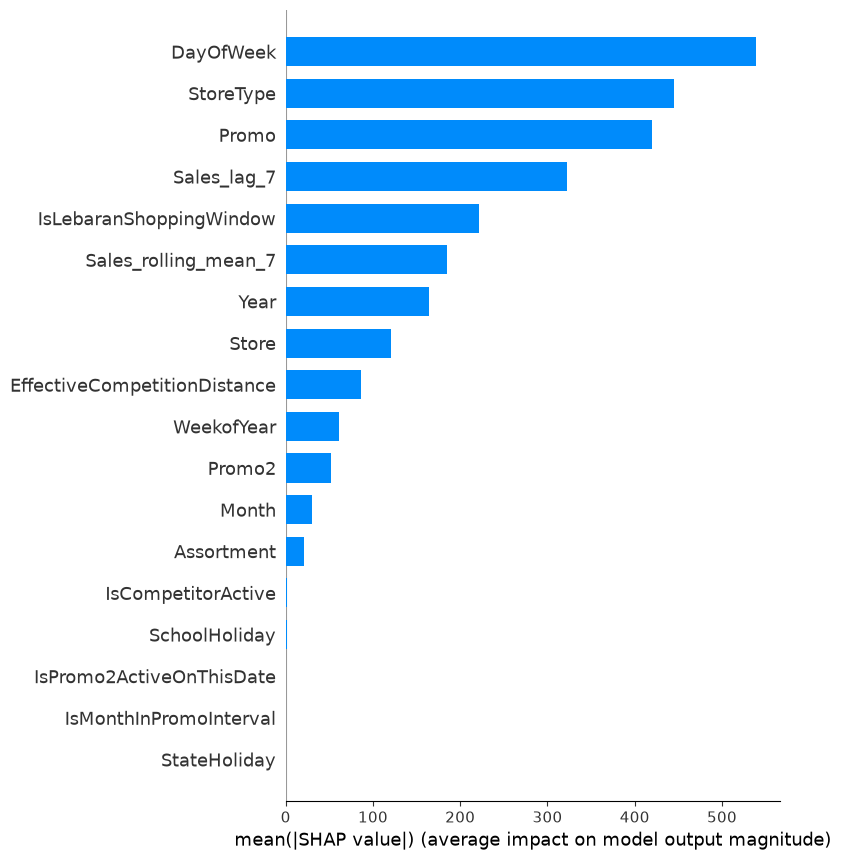

In [51]:
explainer = shap.TreeExplainer(model_v2)
shap_values = explainer.shap_values(X_test_v2)

shap.summary_plot(shap_values, X_test_v2, plot_type='bar')

In [52]:
joblib.dump(model_v2, 'model.pkl')
 
joblib.dump({
    'feature_cols': feature_cols_v2,
    'cat_cols': cat_cols,
}, 'model_metadata.pkl')
 
print("Model dan metadata tersimpan: model.pkl, model_metadata.pkl")
 

Model dan metadata tersimpan: model.pkl, model_metadata.pkl
